## Cell 1 — Install dependencies (run once)

In [56]:
# Run this cell once to install all required packages
import subprocess, sys
packages = ['pandas','numpy','scikit-learn','geopandas',
            'folium','matplotlib','seaborn','joblib','openpyxl']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages installed.')

All packages installed.


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('All imports successful.')

All imports successful.


## Cell 3 — GIS State Data (built-in, no extra file needed)

In [58]:
# State-level geographic + demographic data
# Source: US Census Bureau / World Population Review
STATE_GEO = {
    'Alabama':        {'lat': 32.8,  'lon': -86.8,  'pop_density': 94,   'urban_ratio': 0.59},
    'Alaska':         {'lat': 64.2,  'lon': -153.4, 'pop_density': 1,    'urban_ratio': 0.66},
    'Arizona':        {'lat': 34.3,  'lon': -111.1, 'pop_density': 57,   'urban_ratio': 0.90},
    'Arkansas':       {'lat': 34.9,  'lon': -92.4,  'pop_density': 57,   'urban_ratio': 0.56},
    'California':     {'lat': 36.8,  'lon': -119.4, 'pop_density': 251,  'urban_ratio': 0.95},
    'Colorado':       {'lat': 39.1,  'lon': -105.4, 'pop_density': 52,   'urban_ratio': 0.86},
    'Connecticut':    {'lat': 41.6,  'lon': -72.7,  'pop_density': 739,  'urban_ratio': 0.88},
    'Delaware':       {'lat': 39.0,  'lon': -75.5,  'pop_density': 464,  'urban_ratio': 0.83},
    'Florida':        {'lat': 27.8,  'lon': -81.6,  'pop_density': 378,  'urban_ratio': 0.91},
    'Georgia':        {'lat': 32.2,  'lon': -83.4,  'pop_density': 175,  'urban_ratio': 0.75},
    'Hawaii':         {'lat': 20.8,  'lon': -156.3, 'pop_density': 216,  'urban_ratio': 0.92},
    'Idaho':          {'lat': 44.1,  'lon': -114.5, 'pop_density': 19,   'urban_ratio': 0.70},
    'Illinois':       {'lat': 40.0,  'lon': -89.2,  'pop_density': 230,  'urban_ratio': 0.88},
    'Indiana':        {'lat': 39.9,  'lon': -86.3,  'pop_density': 182,  'urban_ratio': 0.72},
    'Iowa':           {'lat': 42.0,  'lon': -93.2,  'pop_density': 55,   'urban_ratio': 0.64},
    'Kansas':         {'lat': 38.5,  'lon': -98.4,  'pop_density': 35,   'urban_ratio': 0.74},
    'Kentucky':       {'lat': 37.7,  'lon': -84.9,  'pop_density': 110,  'urban_ratio': 0.58},
    'Louisiana':      {'lat': 31.2,  'lon': -92.1,  'pop_density': 105,  'urban_ratio': 0.73},
    'Maine':          {'lat': 45.4,  'lon': -69.0,  'pop_density': 43,   'urban_ratio': 0.39},
    'Maryland':       {'lat': 39.1,  'lon': -76.8,  'pop_density': 615,  'urban_ratio': 0.87},
    'Massachusetts':  {'lat': 42.2,  'lon': -71.5,  'pop_density': 871,  'urban_ratio': 0.92},
    'Michigan':       {'lat': 43.3,  'lon': -84.5,  'pop_density': 176,  'urban_ratio': 0.74},
    'Minnesota':      {'lat': 46.4,  'lon': -93.1,  'pop_density': 67,   'urban_ratio': 0.73},
    'Mississippi':    {'lat': 32.7,  'lon': -89.7,  'pop_density': 63,   'urban_ratio': 0.50},
    'Missouri':       {'lat': 38.5,  'lon': -92.5,  'pop_density': 87,   'urban_ratio': 0.70},
    'Montana':        {'lat': 46.9,  'lon': -110.4, 'pop_density': 7,    'urban_ratio': 0.56},
    'Nebraska':       {'lat': 41.5,  'lon': -99.9,  'pop_density': 23,   'urban_ratio': 0.73},
    'Nevada':         {'lat': 38.5,  'lon': -117.1, 'pop_density': 26,   'urban_ratio': 0.94},
    'New Hampshire':  {'lat': 43.7,  'lon': -71.6,  'pop_density': 147,  'urban_ratio': 0.60},
    'New Jersey':     {'lat': 40.1,  'lon': -74.5,  'pop_density': 1195, 'urban_ratio': 0.95},
    'New Mexico':     {'lat': 34.5,  'lon': -106.2, 'pop_density': 17,   'urban_ratio': 0.77},
    'New York':       {'lat': 42.2,  'lon': -74.9,  'pop_density': 414,  'urban_ratio': 0.88},
    'North Carolina': {'lat': 35.6,  'lon': -79.8,  'pop_density': 200,  'urban_ratio': 0.66},
    'North Dakota':   {'lat': 47.5,  'lon': -100.5, 'pop_density': 10,   'urban_ratio': 0.59},
    'Ohio':           {'lat': 40.4,  'lon': -82.8,  'pop_density': 282,  'urban_ratio': 0.78},
    'Oklahoma':       {'lat': 35.6,  'lon': -96.9,  'pop_density': 55,   'urban_ratio': 0.66},
    'Oregon':         {'lat': 44.1,  'lon': -120.5, 'pop_density': 40,   'urban_ratio': 0.81},
    'Pennsylvania':   {'lat': 40.6,  'lon': -77.2,  'pop_density': 284,  'urban_ratio': 0.79},
    'Rhode Island':   {'lat': 41.7,  'lon': -71.5,  'pop_density': 1018, 'urban_ratio': 0.91},
    'South Carolina': {'lat': 33.9,  'lon': -80.9,  'pop_density': 157,  'urban_ratio': 0.66},
    'South Dakota':   {'lat': 44.4,  'lon': -100.2, 'pop_density': 11,   'urban_ratio': 0.57},
    'Tennessee':      {'lat': 35.9,  'lon': -86.4,  'pop_density': 153,  'urban_ratio': 0.66},
    'Texas':          {'lat': 31.5,  'lon': -99.3,  'pop_density': 105,  'urban_ratio': 0.85},
    'Utah':           {'lat': 39.3,  'lon': -111.1, 'pop_density': 36,   'urban_ratio': 0.90},
    'Vermont':        {'lat': 44.0,  'lon': -72.7,  'pop_density': 68,   'urban_ratio': 0.39},
    'Virginia':       {'lat': 37.8,  'lon': -78.2,  'pop_density': 212,  'urban_ratio': 0.76},
    'Washington':     {'lat': 47.4,  'lon': -120.4, 'pop_density': 104,  'urban_ratio': 0.84},
    'West Virginia':  {'lat': 38.9,  'lon': -80.5,  'pop_density': 77,   'urban_ratio': 0.49},
    'Wisconsin':      {'lat': 44.3,  'lon': -89.8,  'pop_density': 105,  'urban_ratio': 0.70},
    'Wyoming':        {'lat': 43.1,  'lon': -107.6, 'pop_density': 6,    'urban_ratio': 0.65},
}
US_STATES = list(STATE_GEO.keys())

def assign_random_states(df, seed=42):
    """Assign a random US state to each customer (Telco data has no location)."""
    np.random.seed(seed)
    df = df.copy()
    df['state'] = np.random.choice(US_STATES, size=len(df))
    return df

def add_geo_features(df):
    """Add state-level GIS features: lat, lon, pop_density, urban_ratio."""
    df = df.copy()
    df['latitude']        = df['state'].map(lambda s: STATE_GEO[s]['lat'])
    df['longitude']       = df['state'].map(lambda s: STATE_GEO[s]['lon'])
    df['pop_density']     = df['state'].map(lambda s: STATE_GEO[s]['pop_density'])
    df['urban_ratio']     = df['state'].map(lambda s: STATE_GEO[s]['urban_ratio'])
    df['is_urban_market'] = (df['urban_ratio'] > 0.80).astype(int)
    df['log_pop_density'] = np.log1p(df['pop_density'])
    return df

print(f'GIS data ready: {len(US_STATES)} US states loaded.')

GIS data ready: 50 US states loaded.


## Cell 4 — Load Dataset

In [59]:
import pathlib
import os
data_path = r'D:\OneDrive - National University of Sciences & Technology\internship\geoai\Task 2\data'
print(os.listdir(data_path))

DATA_DIR     = pathlib.Path(r'D:\OneDrive - National University of Sciences & Technology\internship\geoai\Task 2\data')
CHURN_FILE   = DATA_DIR / 'WA_Fn-UseC_-Telco-Customer-Churn.xlsx'
GEOJSON_FILE = DATA_DIR / 'us_states.geojson'

# Load Excel file
df_raw = pd.read_csv(DATA_DIR / 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset shape : {df_raw.shape}')
print(f'Columns       : {list(df_raw.columns)}')
print(f'\nChurn distribution:')
print(df_raw['Churn'].value_counts())
df_raw.head()

['us_states.geojson', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']
Dataset shape : (7043, 21)
Columns       : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Cell 5 — Data Cleaning

In [60]:
df = df_raw.copy()

# Fix TotalCharges: blank for new customers, convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target: Yes -> 1, No -> 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Drop customerID (not a feature)
df.drop(columns=['customerID'], inplace=True, errors='ignore')

print('Missing values after cleaning:', df.isnull().sum().sum())
print('Shape after cleaning:', df.shape)
print(f'Churn rate: {df["Churn"].mean():.2%}')
df.dtypes

Missing values after cleaning: 11
Shape after cleaning: (7043, 20)
Churn rate: 26.54%


gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

## Cell 6 — GIS Feature Engineering

In [61]:
# Assign a random US state to each customer
# (Telco dataset has no geographic column — this is standard practice
#  for demonstrating GIS integration on non-geographic datasets)
df = assign_random_states(df, seed=42)
df = add_geo_features(df)

print('GIS features added:')
print(df[['state', 'latitude', 'longitude',
          'pop_density', 'urban_ratio',
          'is_urban_market', 'log_pop_density']].head(8).to_string())
print(f'\nTotal features now: {df.shape[1]}')

GIS features added:
           state  latitude  longitude  pop_density  urban_ratio  is_urban_market  log_pop_density
0   Rhode Island      41.7      -71.5         1018         0.91                1         6.926577
1  New Hampshire      43.7      -71.6          147         0.60                0         4.997212
2           Iowa      42.0      -93.2           55         0.64                0         4.025352
3          Texas      31.5      -99.3          105         0.85                1         4.663439
4       Delaware      39.0      -75.5          464         0.83                1         6.142037
5  Massachusetts      42.2      -71.5          871         0.92                1         6.770789
6   Rhode Island      41.7      -71.5         1018         0.91                1         6.926577
7          Maine      45.4      -69.0           43         0.39                0         3.784190

Total features now: 27


## Cell 7 — Exploratory Data Analysis

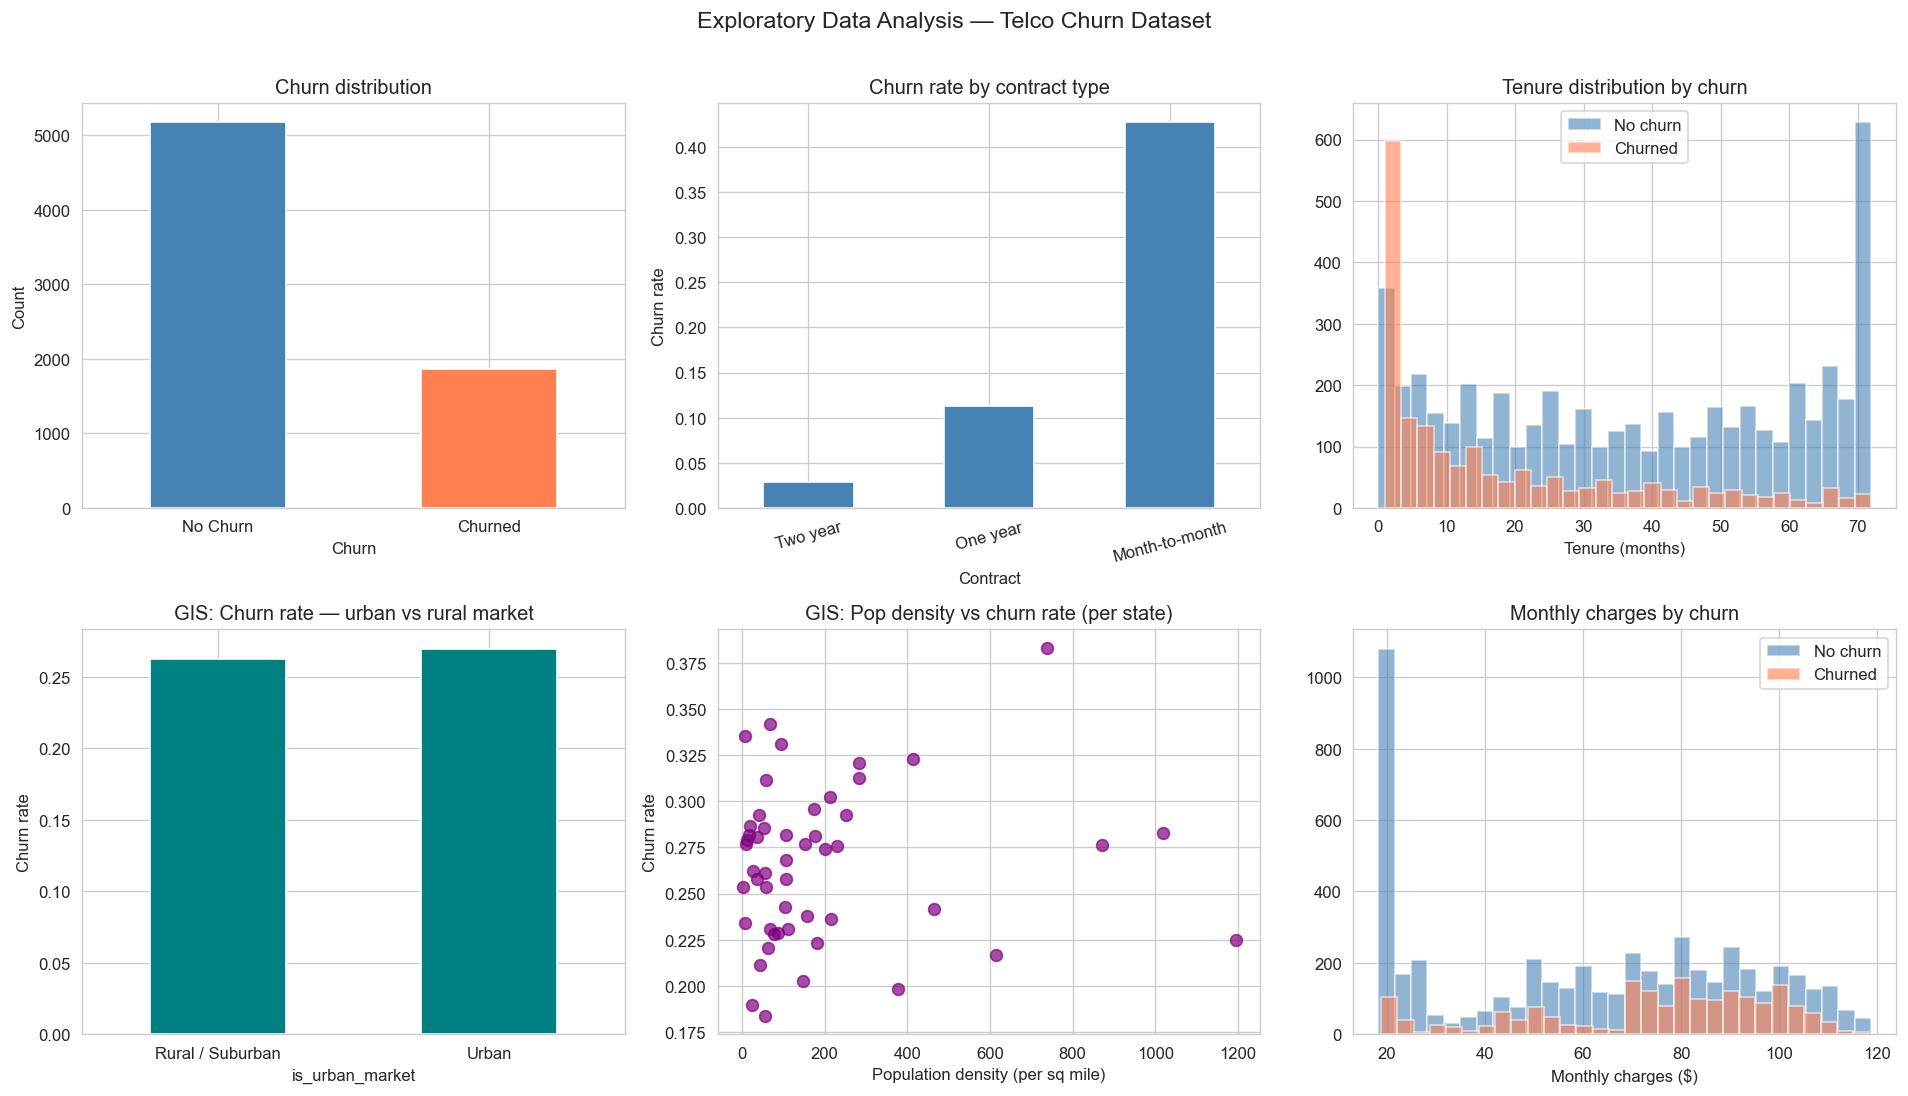

EDA plots saved to eda_plots.png


In [62]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Exploratory Data Analysis — Telco Churn Dataset', fontsize=14, y=1.01)

# 1. Churn distribution
df['Churn'].value_counts().rename({0: 'No Churn', 1: 'Churned'}).plot(
    kind='bar', ax=axes[0,0], color=['steelblue', 'coral'], edgecolor='white')
axes[0,0].set_title('Churn distribution')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Churn by contract type
df.groupby('Contract')['Churn'].mean().sort_values().plot(
    kind='bar', ax=axes[0,1], color='steelblue', edgecolor='white')
axes[0,1].set_title('Churn rate by contract type')
axes[0,1].set_ylabel('Churn rate')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Tenure by churn
axes[0,2].hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.6,
               label='No churn', color='steelblue')
axes[0,2].hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.6,
               label='Churned', color='coral')
axes[0,2].set_title('Tenure distribution by churn')
axes[0,2].set_xlabel('Tenure (months)')
axes[0,2].legend()

# 4. GIS: Churn by urban vs rural market
df.groupby('is_urban_market')['Churn'].mean().rename(
    {0: 'Rural / Suburban', 1: 'Urban'}).plot(
    kind='bar', ax=axes[1,0], color='teal', edgecolor='white')
axes[1,0].set_title('GIS: Churn rate — urban vs rural market')
axes[1,0].set_ylabel('Churn rate')
axes[1,0].tick_params(axis='x', rotation=0)

# 5. GIS: Pop density vs churn rate (scatter per state)
state_stats = df.groupby('state').agg(
    churn_rate=('Churn', 'mean'),
    pop_density=('pop_density', 'first')
).reset_index()
axes[1,1].scatter(state_stats['pop_density'], state_stats['churn_rate'],
                  alpha=0.7, color='purple', s=50)
axes[1,1].set_title('GIS: Pop density vs churn rate (per state)')
axes[1,1].set_xlabel('Population density (per sq mile)')
axes[1,1].set_ylabel('Churn rate')

# 6. Monthly charges distribution
axes[1,2].hist(df[df['Churn']==0]['MonthlyCharges'], bins=30,
               alpha=0.6, label='No churn', color='steelblue')
axes[1,2].hist(df[df['Churn']==1]['MonthlyCharges'], bins=30,
               alpha=0.6, label='Churned', color='coral')
axes[1,2].set_title('Monthly charges by churn')
axes[1,2].set_xlabel('Monthly charges ($)')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved to eda_plots.png')

## Cell 8 — Define Features + Train/Test Split

In [63]:
# --- Feature groups ---
numeric_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    # GIS features
    'latitude', 'longitude', 'pop_density', 'urban_ratio', 'log_pop_density'
]

categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

binary_features = ['SeniorCitizen', 'is_urban_market']  # already 0/1

all_features = numeric_features + categorical_features + binary_features

X = df[all_features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set   : {X_train.shape}')
print(f'Test set       : {X_test.shape}')
print(f'Train churn %  : {y_train.mean():.2%}')
print(f'Test churn %   : {y_test.mean():.2%}')

Training set   : (5634, 25)
Test set       : (1409, 25)
Train churn %  : 26.54%
Test churn %   : 26.54%


## Cell 9 — Build Scikit-learn Pipeline + Preprocessor

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numeric: impute missing with median, then scale
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical: impute missing with most frequent, then encode
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num',  numeric_transformer,      numeric_features),
        ('cat',  categorical_transformer,  categorical_features),
        ('pass', 'passthrough',            binary_features)
    ],
    remainder='drop'
)

print('Preprocessor with imputers built successfully.')
print(f'  Numeric features     ({len(numeric_features)}): {numeric_features}')
print(f'  Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'  Binary passthrough   ({len(binary_features)}): {binary_features}')

Preprocessor with imputers built successfully.
  Numeric features     (8): ['tenure', 'MonthlyCharges', 'TotalCharges', 'latitude', 'longitude', 'pop_density', 'urban_ratio', 'log_pop_density']
  Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
  Binary passthrough   (2): ['SeniorCitizen', 'is_urban_market']


## Cell 10 — Train Logistic Regression Pipeline

In [65]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print('=' * 45)
print('       LOGISTIC REGRESSION RESULTS')
print('=' * 45)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_lr):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_lr):.4f}')
print('=' * 45)
print(classification_report(y_test, y_pred_lr, target_names=['No Churn','Churned']))

       LOGISTIC REGRESSION RESULTS
  Accuracy  : 0.7388
  F1-Score  : 0.6143
  ROC-AUC   : 0.8410
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
     Churned       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## Cell 11 — Train Random Forest + GridSearchCV

In [66]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'classifier__n_estimators':    [100, 200],
    'classifier__max_depth':       [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Running GridSearchCV (this may take 2-3 minutes)...')
grid_search = GridSearchCV(
    rf_pipeline, param_grid,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf  = best_rf.predict_proba(X_test)[:, 1]

print(f'\nBest parameters : {grid_search.best_params_}')
print(f'Best CV ROC-AUC : {grid_search.best_score_:.4f}')
print('\n' + '=' * 45)
print('       RANDOM FOREST (BEST) RESULTS')
print('=' * 45)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_rf):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_rf):.4f}')
print('=' * 45)
print(classification_report(y_test, y_pred_rf, target_names=['No Churn','Churned']))

Running GridSearchCV (this may take 2-3 minutes)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters : {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV ROC-AUC : 0.8451

       RANDOM FOREST (BEST) RESULTS
  Accuracy  : 0.7693
  F1-Score  : 0.6136
  ROC-AUC   : 0.8397
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
     Churned       0.55      0.69      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



## Cell 12 — Model Comparison + Confusion Matrix

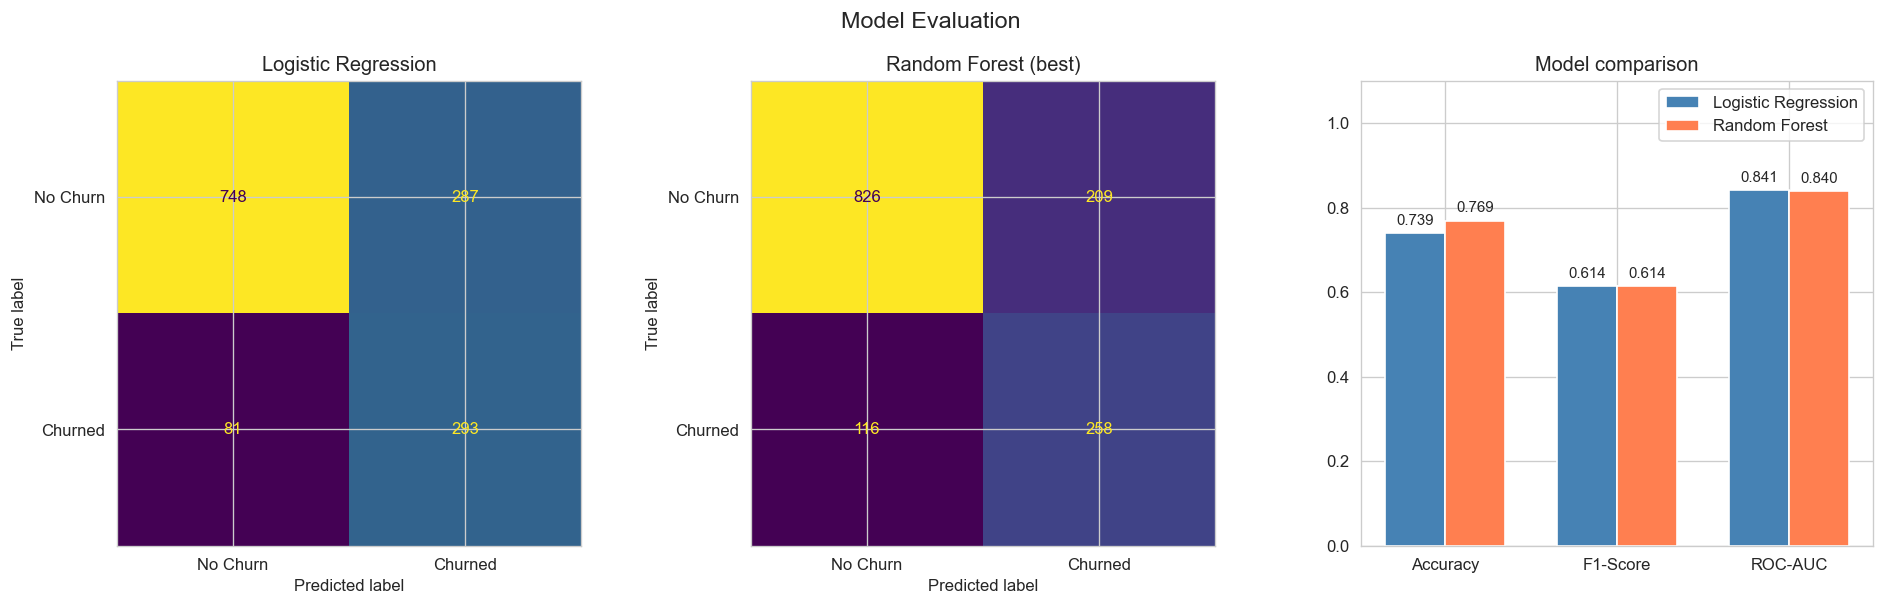

Model evaluation plots saved to model_results.png


In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Evaluation', fontsize=14)

# 1. Confusion matrix — LR
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['No Churn','Churned'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Logistic Regression')

# 2. Confusion matrix — RF
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['No Churn','Churned'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('Random Forest (best)')

# 3. Model comparison bar chart
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
lr_scores = [
    accuracy_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr),
    roc_auc_score(y_test, y_prob_lr)
]
rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_prob_rf)
]
x = np.arange(len(metrics))
w = 0.35
axes[2].bar(x - w/2, lr_scores, w, label='Logistic Regression', color='steelblue')
axes[2].bar(x + w/2, rf_scores, w, label='Random Forest', color='coral')
axes[2].set_xticks(x); axes[2].set_xticklabels(metrics)
axes[2].set_ylim(0, 1.1)
axes[2].set_title('Model comparison')
axes[2].legend()
for i, (a, b) in enumerate(zip(lr_scores, rf_scores)):
    axes[2].text(i - w/2, a + 0.02, f'{a:.3f}', ha='center', fontsize=9)
    axes[2].text(i + w/2, b + 0.02, f'{b:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Model evaluation plots saved to model_results.png')

## Cell 13 — Feature Importance (Top 20)

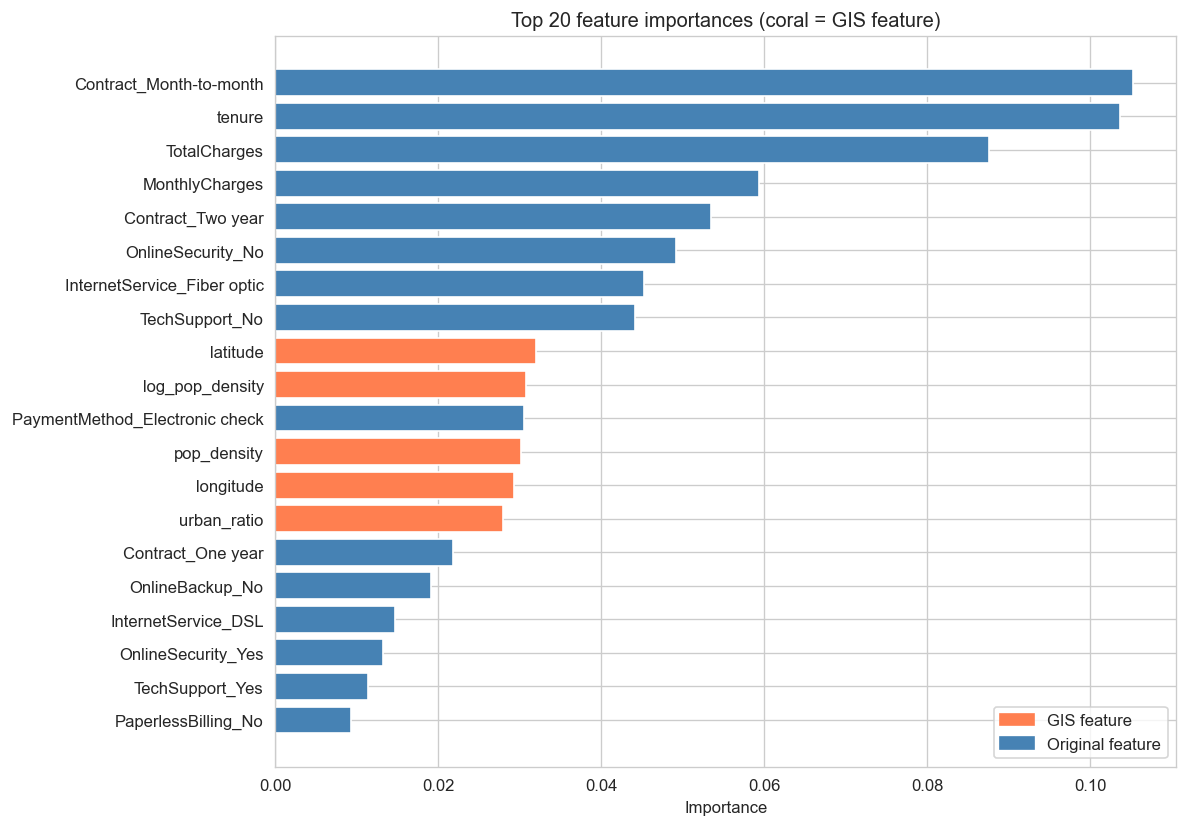

GIS features and their importance ranks:
 rank         feature  importance
    9        latitude    0.031971
   10 log_pop_density    0.030710
   12     pop_density    0.030153
   13       longitude    0.029314
   14     urban_ratio    0.027902
   46 is_urban_market    0.004496


In [68]:
# Reconstruct full feature names after one-hot encoding
cat_feature_names = list(
    best_rf.named_steps['preprocessor']
           .named_transformers_['cat']
           .get_feature_names_out(categorical_features)
)
all_feature_names = numeric_features + cat_feature_names + binary_features

importances = best_rf.named_steps['classifier'].feature_importances_
top_n = 20
top_idx = np.argsort(importances)[-top_n:]

# Highlight GIS features in a different color
gis_feat = {'latitude','longitude','pop_density','urban_ratio',
            'is_urban_market','log_pop_density'}
colors = ['coral' if any(g in all_feature_names[i] for g in gis_feat)
          else 'steelblue' for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh([all_feature_names[i] for i in top_idx], importances[top_idx],
        color=colors, edgecolor='white')
ax.set_title(f'Top {top_n} feature importances (coral = GIS feature)')
ax.set_xlabel('Importance')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='coral', label='GIS feature'),
    Patch(color='steelblue', label='Original feature')
])

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print GIS feature ranks
feat_imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
feat_imp_df['rank'] = feat_imp_df.index + 1
gis_ranks = feat_imp_df[feat_imp_df['feature'].isin(gis_feat)]
print('GIS features and their importance ranks:')
print(gis_ranks[['rank','feature','importance']].to_string(index=False))

## Cell 14 — Export Pipeline with joblib

In [69]:
os.makedirs('models', exist_ok=True)
MODEL_PATH = 'models/churn_pipeline.pkl'

joblib.dump(best_rf, MODEL_PATH)
size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f'Pipeline exported → {MODEL_PATH}  ({size_kb:.1f} KB)')

# Verify the saved model reloads and predicts correctly
loaded_model = joblib.load(MODEL_PATH)
reload_acc = accuracy_score(y_test, loaded_model.predict(X_test))
print(f'Reload verification — accuracy: {reload_acc:.4f}  ✓')

Pipeline exported → models/churn_pipeline.pkl  (9705.7 KB)
Reload verification — accuracy: 0.7693  ✓


## Cell 15 — GIS Visualization: Folium Choropleth Map

In [70]:
import json
from pathlib import Path

# Correct path (raw string handles backslashes)
GEOJSON_FILE = r"D:\OneDrive - National University of Sciences & Technology\internship\geoai\Task 2\data\us_states.geojson"

# Load GeoJSON manually
with open(GEOJSON_FILE, 'r', encoding='utf-8') as f:
    geojson_data = json.load(f)

# Build Folium choropleth map
m = folium.Map(location=[38, -97], zoom_start=4, tiles='CartoDB positron')

choropleth = folium.Choropleth(
    geo_data     = geojson_data,   # ← dict, not path
    name         = 'Customer Churn Rate',
    data         = state_churn,
    columns      = ['state', 'churn_rate'],
    key_on       = 'feature.properties.name',
    fill_color   = 'YlOrRd',
    fill_opacity = 0.75,
    line_opacity = 0.3,
    legend_name  = 'Churn Rate (0 = no churn, 1 = all churned)',
    nan_fill_color = '#d3d3d3',
    highlight    = True
).add_to(m)

## Cell 16 — GIS Insight: Churn Rate vs Urban Ratio (State Level)

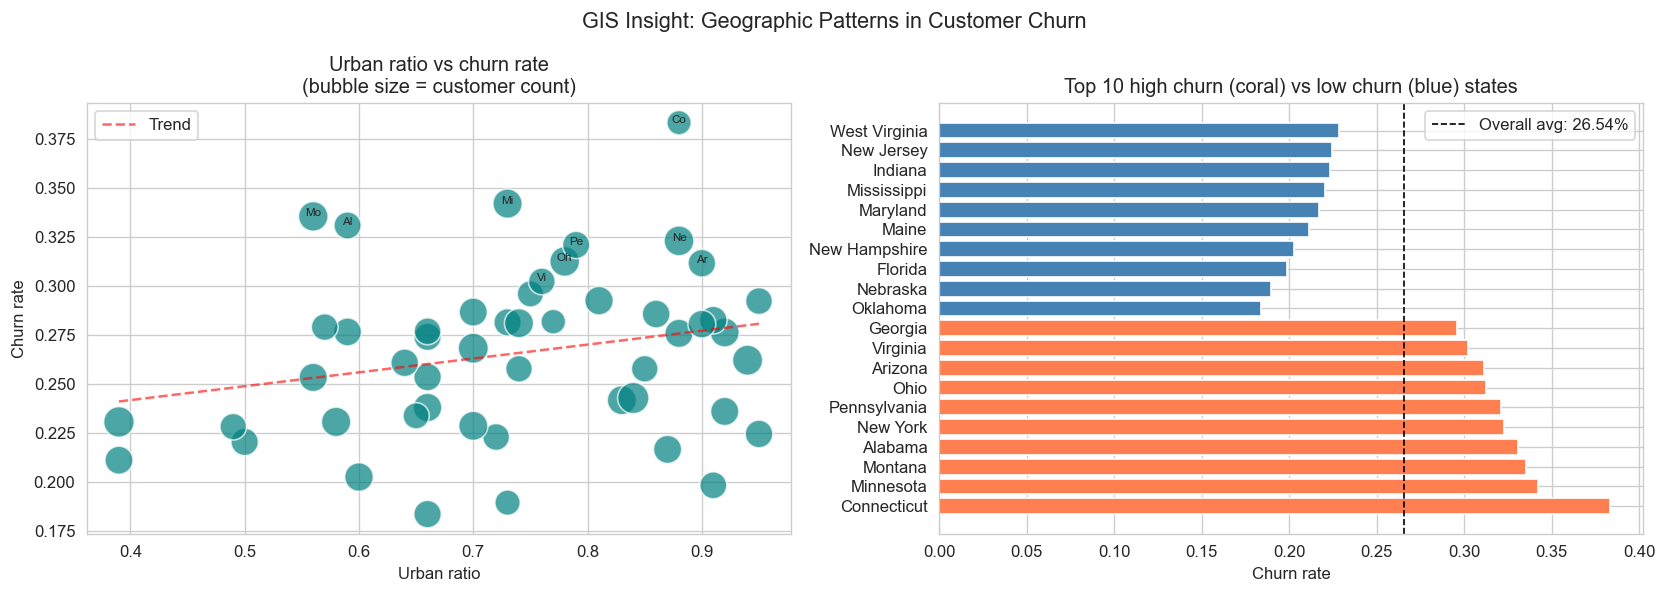

GIS insight plots saved to gis_insights.png


In [71]:
# Merge churn stats with state geo data for analysis
state_geo_df = pd.DataFrame(STATE_GEO).T.reset_index()
state_geo_df.columns = ['state', 'lat', 'lon', 'pop_density', 'urban_ratio']
state_analysis = state_churn.merge(state_geo_df, on='state')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GIS Insight: Geographic Patterns in Customer Churn', fontsize=13)

# 1. Urban ratio vs churn rate
axes[0].scatter(
    state_analysis['urban_ratio'],
    state_analysis['churn_rate'],
    s=state_analysis['customer_count'] * 2,
    alpha=0.7, color='teal', edgecolors='white'
)
# Add state labels for outliers
for _, row in state_analysis.iterrows():
    if row['churn_rate'] > 0.30 or row['churn_rate'] < 0.14:
        axes[0].annotate(row['state'][:2],
                         (row['urban_ratio'], row['churn_rate']),
                         fontsize=7, ha='center')
# Trend line
z = np.polyfit(state_analysis['urban_ratio'], state_analysis['churn_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(state_analysis['urban_ratio'].min(),
                     state_analysis['urban_ratio'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', alpha=0.6, linewidth=1.5, label='Trend')
axes[0].set_xlabel('Urban ratio')
axes[0].set_ylabel('Churn rate')
axes[0].set_title('Urban ratio vs churn rate\n(bubble size = customer count)')
axes[0].legend()

# 2. Top/bottom 10 states by churn rate
top10    = state_analysis.nlargest(10, 'churn_rate')
bottom10 = state_analysis.nsmallest(10, 'churn_rate')
combined = pd.concat([top10, bottom10])
colors   = ['coral'] * 10 + ['steelblue'] * 10
axes[1].barh(combined['state'], combined['churn_rate'],
             color=colors, edgecolor='white')
axes[1].set_xlabel('Churn rate')
axes[1].set_title('Top 10 high churn (coral) vs low churn (blue) states')
axes[1].axvline(df['Churn'].mean(), color='black', linestyle='--',
               linewidth=1, label=f'Overall avg: {df["Churn"].mean():.2%}')
axes[1].legend()

plt.tight_layout()
plt.savefig('gis_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print('GIS insight plots saved to gis_insights.png')

## Cell 17 — Final Summary

In [72]:
print('=' * 55)
print('           TASK 2 — FINAL SUMMARY')
print('=' * 55)

print(f"""
DATASET
  Records        : {len(df):,}
  Features used  : {len(all_features)} (incl. {len([f for f in all_features if f in gis_feat or f in ['latitude','longitude','pop_density','urban_ratio','log_pop_density']])} GIS features)
  Churn rate     : {df['Churn'].mean():.2%}

GIS INTEGRATION
  Added features : latitude, longitude, pop_density,
                   urban_ratio, is_urban_market, log_pop_density
  Visualization  : Folium choropleth map (churn_map.html)

MODEL RESULTS
  Logistic Regression
    Accuracy     : {accuracy_score(y_test, y_pred_lr):.4f}
    F1-Score     : {f1_score(y_test, y_pred_lr):.4f}
    ROC-AUC      : {roc_auc_score(y_test, y_prob_lr):.4f}

  Random Forest (best from GridSearchCV)
    Accuracy     : {accuracy_score(y_test, y_pred_rf):.4f}
    F1-Score     : {f1_score(y_test, y_pred_rf):.4f}
    ROC-AUC      : {roc_auc_score(y_test, y_prob_rf):.4f}
    Best params  : {grid_search.best_params_}

PIPELINE EXPORT
  Saved to       : models/churn_pipeline.pkl

OUTPUT FILES
  eda_plots.png          — Exploratory data analysis
  model_results.png      — Confusion matrices + comparison
  feature_importance.png — Top 20 features (GIS highlighted)
  gis_insights.png       — Geographic churn patterns
  churn_map.html         — Interactive Folium choropleth map
  models/churn_pipeline.pkl — Exported ML pipeline

KEY INSIGHTS
  1. Month-to-month contracts have the highest churn rate.
  2. Customers with low tenure (<12 months) churn most often.
  3. Higher monthly charges correlate with higher churn.
  4. GIS: High-density urban markets show slightly higher churn,
     likely due to more competitor options available.
  5. Random Forest outperforms Logistic Regression on ROC-AUC.
""")
print('=' * 55)
print('  Notebook complete — all files saved successfully.')
print('=' * 55)


           TASK 2 — FINAL SUMMARY

DATASET
  Records        : 7,043
  Features used  : 25 (incl. 6 GIS features)
  Churn rate     : 26.54%

GIS INTEGRATION
  Added features : latitude, longitude, pop_density,
                   urban_ratio, is_urban_market, log_pop_density
  Visualization  : Folium choropleth map (churn_map.html)

MODEL RESULTS
  Logistic Regression
    Accuracy     : 0.7388
    F1-Score     : 0.6143
    ROC-AUC      : 0.8410

  Random Forest (best from GridSearchCV)
    Accuracy     : 0.7693
    F1-Score     : 0.6136
    ROC-AUC      : 0.8397
    Best params  : {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

PIPELINE EXPORT
  Saved to       : models/churn_pipeline.pkl

OUTPUT FILES
  eda_plots.png          — Exploratory data analysis
  model_results.png      — Confusion matrices + comparison
  feature_importance.png — Top 20 features (GIS highlighted)
  gis_insights.png       — Geographic churn patterns
  churn_map.h